In [1]:
!pip install pandas

In [2]:
import pandas as pd

df = pd.read_csv('2025_Airbnb_NYC_listings.csv')

print(df.head())

   Unnamed: 0     id       source  \
0           0  36121  city scrape   
1           1  36647  city scrape   
2           2  38663  city scrape   
3           3  38833  city scrape   
4           4  39282  city scrape   

                                                name  \
0                 Lg Rm in Historic Prospect Heights   
1  1 Bedroom & your own Bathroom, Elevator Apartment   
2                   Luxury Brownstone in Boerum Hill   
3                 Spectacular West Harlem Garden Apt   
4                    “Work-from-home” from OUR home.   

                                         description  \
0  Cozy space share in the heart of a great neigh...   
1  Private bedroom with your own bathroom in a 2 ...   
2  Beautiful, large home in great hipster neighbo...   
3  This is a very large and unique  space. An inc...   
4  *Monthly Discount will automatically apply <br...   

                               neighborhood_overview  host_id host_name  \
0  Full of tree-lined street

In [3]:
df = pd.read_csv('2025_Airbnb_NYC_listings.csv')

print(list(df.columns))
print(f"\n총 컬럼 개수: {len(df.columns)}개")

['Unnamed: 0', 'id', 'source', 'name', 'description', 'neighborhood_overview', 'host_id', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'calendar_last_scraped', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews

In [3]:
df = pd.read_csv('2025_Airbnb_NYC_listings.csv')

#주요컬럼 : 호스트, 숙소명, 숙소유형, 숙소위치, 가격, 리뷰개수, 평점
selected_cols = [
    'host_name', 'name', 'room_type', 
    'neighbourhood_group_cleansed', 'price', 
    'number_of_reviews', 'review_scores_rating'
]

data = df[selected_cols].copy()

#한글로 컬럼 이름 바꾸기
data.columns = ['호스트', '숙소명', '숙소유형', '위치(구)', '가격', '리뷰수', '평점']

#가격 데이터 숫자형으로 변환
data['가격'] = data['가격'].str.replace('$', '').str.replace(',', '').astype(float)

display(data.head())

,호스트,숙소명,숙소유형,위치(구),가격,리뷰수,평점
0,Michael,Lg Rm in Historic Prospect Heights,Private room,Brooklyn,200.0,9,4.88
1,Irene,"1 Bedroom & your own Bathroom, Elevator Apartment",Private room,Manhattan,82.0,102,4.77
2,Sarah,Luxury Brownstone in Boerum Hill,Private room,Brooklyn,765.0,43,4.70
3,Matthew,Spectacular West Harlem Garden Apt,Entire home/apt,Manhattan,139.0,241,4.85
4,Gustavo,“Work-from-home” from OUR home.,Private room,Brooklyn,130.0,274,4.82


In [4]:
df = pd.read_csv('2025_Airbnb_NYC_listings.csv')

#가격 데이터 숫자형으로 먼저 변환
df['price'] = df['price'].str.replace('$', '').str.replace(',', '').astype(float)

#A: 중요한 컬럼(이름, 호스트명, 가격)이 없는 행은 삭제
df_cleaned = df.dropna(subset=['name', 'price'])

#B: 너무 비어있는 컬럼(예: neighborhood_overview 등)은 컬럼 자체를 삭제 / 데이터의 50% 이상이 비어있는 컬럼 삭제
#df_cleaned = df_cleaned.dropna(thresh=len(df_cleaned)*0.5, axis=1)

#C: 숫자형 데이터 중 남은 결측치는 0으로 채우기
num = df_cleaned.select_dtypes(include=['number']).columns
df_cleaned[num] = df_cleaned[num].fillna(0)

print(f"처음 데이터 개수: {len(df)}")
print(f"결측치 제거 후 데이터 개수: {len(df_cleaned)}")
print(f"남은 컬럼 개수: {len(df_cleaned.columns)}")

#정제 데이터 확인
display(df_cleaned.head())

처음 데이터 개수: 22308
결측치 제거 후 데이터 개수: 22308
남은 컬럼 개수: 73


,Unnamed: 0,id,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,0,36121,city scrape,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,Full of tree-lined streets and beautiful brown...,62165,Michael,2009-12-11,"New York, NY",...,5.00,5.00,5.00,NaN,f,1,0,1,0,0.05
1,1,36647,city scrape,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,"Manhattan, SE corner of 2nd Ave/ E. 110th street",157798,Irene,2010-07-04,"New York, NY",...,4.90,4.38,4.71,NaN,f,1,0,1,0,0.58
2,2,38663,city scrape,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...","diverse, lively, hip, cool: loaded with restau...",165789,Sarah,2010-07-13,"New York, NY",...,4.88,4.86,4.62,OSE-STRREG-0001784,f,1,0,1,0,0.28
3,3,38833,city scrape,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,West Harlem is now packed with great restauran...,166532,Matthew,2010-07-14,"New York, NY",...,4.96,4.79,4.82,OSE-STRREG-0000476,f,1,1,0,0,1.36
4,4,39282,city scrape,“Work-from-home” from OUR home.,*Monthly Discount will automatically apply <br...,THE NEIGHBORHOOD:<br />Our apartment is locate...,168525,Gustavo,2010-07-16,"New York, NY",...,4.88,4.85,4.78,OSE-STRREG-0001150,f,2,0,2,0,1.54


In [5]:
df = pd.read_csv('2025_Airbnb_NYC_listings.csv')

#숫자형 데이터인 컬럼만 골라내기
num_cols = df.select_dtypes(include=['number'])

#결측치(NaN) 개수 계산
na_counts = num_cols.isnull().sum()

#0인 값의 개수 계산
zero = (num_cols == 0).sum()

audit = pd.DataFrame({
    '결측치(NaN) 개수': na_counts,
    '0인 값 개수': zero
})

#값이 0보다 큰 것만
print(audit[ (audit['결측치(NaN) 개수'] > 0) | (audit['0인 값 개수'] > 0) ])

                                              결측치(NaN) 개수  0인 값 개수
Unnamed: 0                                              0        1
host_listings_count                                    20        0
host_total_listings_count                              20        0
bathrooms                                               6      434
bedrooms                                               49     2138
beds                                                   79      635
calendar_updated                                    22308        0
availability_30                                         0     5519
availability_60                                         0     3514
availability_90                                         0     2421
availability_365                                        0      168
number_of_reviews                                       0     6798
number_of_reviews_ltm                                   0    12234
number_of_reviews_l30d                                  0    1

In [6]:
#결측치가 왜 발생했는지?
df = pd.read_csv('2025_Airbnb_NYC_listings.csv')

#A : 수치형 데이터 중에서 0이나 결측치가 많은 컬럼 확인
# 리뷰 점수가 없는 숙소가 얼마나 있는지 확인
x_reviews = df['review_scores_rating'].isnull().sum()
print(f"리뷰 점수가 없는 숙소: {x_reviews}개")

#B : '리뷰 점수'가 없는 숙소들은 '리뷰 개수'도 0일까? (도메인 규칙 확인)
no_score = df[df['review_scores_rating'].isnull()]['number_of_reviews'].unique()
print(f"리뷰 점수 없는 숙소들의 리뷰 개수 종류: {no_score}")

#[0] : 점수가 없는 건 리뷰가 쌓이지 않아서

리뷰 점수가 없는 숙소: 6798개
리뷰 점수 없는 숙소들의 리뷰 개수 종류: [0]


In [7]:
df = pd.read_csv('2025_Airbnb_NYC_listings.csv')

print(df['minimum_nights'].describe())

count    22308.000000
mean        27.249417
std         32.428943
min          1.000000
25%         30.000000
50%         30.000000
75%         30.000000
max        730.000000
Name: minimum_nights, dtype: float64


뉴욕주 다세대 주택법 : 아파트 같은 다세대 주택(3세대 이상 거주 빌딩)의 경우, 집주인(호스트)이 함께 거주하지 않으면서 30일 미만으로 집 전체를 대여하는 것을 불법으로 규정함

그래서 많은 호스트가 실제로는 짧게 빌려도 데이터상에는 '30박'이라고 기입함

In [8]:
df = pd.read_csv('2025_Airbnb_NYC_listings.csv')

#30박 이상으로 설정된 숙소는 전체의 몇 %?
long_term = (df['minimum_nights'] >= 30).mean() * 100
print(f"\n최소 숙박일이 30박 이상인 숙소 비중: {long_term :.2f}%")


최소 숙박일이 30박 이상인 숙소 비중: 80.43%


30일 이상인 숙소가 80% 이상
이 데이터 분석으로 알 수 있는 인사이트 : 뉴욕 에어비앤비 시장이 '단기 여행자'를 위한 곳이 아니라 '중장기 체류자' 위주로 완전히 재편됐다.

어쩌면 80%의 호스트가 법(뉴욕주 다세대 주택법) 때문에 '30박'이라는 거짓말을 치고 있을 수도 있음

In [10]:
import pandas as pd

df = pd.read_csv('2025_Airbnb_NYC_listings.csv')

print(df.head())

   Unnamed: 0     id       source  \
0           0  36121  city scrape   
1           1  36647  city scrape   
2           2  38663  city scrape   
3           3  38833  city scrape   
4           4  39282  city scrape   

                                                name  \
0                 Lg Rm in Historic Prospect Heights   
1  1 Bedroom & your own Bathroom, Elevator Apartment   
2                   Luxury Brownstone in Boerum Hill   
3                 Spectacular West Harlem Garden Apt   
4                    “Work-from-home” from OUR home.   

                                         description  \
0  Cozy space share in the heart of a great neigh...   
1  Private bedroom with your own bathroom in a 2 ...   
2  Beautiful, large home in great hipster neighbo...   
3  This is a very large and unique  space. An inc...   
4  *Monthly Discount will automatically apply <br...   

                               neighborhood_overview  host_id host_name  \
0  Full of tree-lined street

In [20]:
df['host_response_rate'].describe()

count     17915
unique       65
top        100%
freq      12885
Name: host_response_rate, dtype: object

In [ ]:
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

expensive_listings = df[df['price'] >= 20000]
display_cols = ['name', 'neighbourhood_cleansed', 'room_type', 'price', 'number_of_reviews']

print(f"2만 달러 이상 숙소 개수: {len(expensive_listings)}개")
print("-" * 50)
print(expensive_listings[display_cols].sort_values(by='price', ascending=False))

2만 달러 이상 숙소 개수: 3개
--------------------------------------------------
                                     name neighbourhood_cleansed  \
14131       1-Bedroom Hotel Suite - 1 bed                   SoHo   
14132  2 Connecting Hotel Suites - 2 beds                   SoHo   
14133      1-Bedroom Hotel Suite - 2 beds                   SoHo   

          room_type    price  number_of_reviews  
14131  Private room  20000.0                  0  
14132  Private room  20000.0                  0  
14133  Private room  20000.0                  0  


In [31]:
df['minimum_nights'].value_counts()

minimum_nights
30     16138
1       2259
31      1297
2        896
3        661
       ...  
20         1
182        1
81         1
41         1
330        1
Name: count, Length: 76, dtype: int64

In [34]:
df['minimum_minimum_nights'].sort_values()

16817      1.0
18352      1.0
18351      1.0
18350      1.0
4044       1.0
         ...  
4888     730.0
4887     730.0
4840     730.0
4682     730.0
4828     730.0
Name: minimum_minimum_nights, Length: 22308, dtype: float64

In [42]:
#결측치 제거
df = df.dropna(subset=['has_availability'])
print(df)

       Unnamed: 0                   id       source  \
0               0                36121  city scrape   
1               1                36647  city scrape   
2               2                38663  city scrape   
3               3                38833  city scrape   
4               4                39282  city scrape   
...           ...                  ...          ...   
22303       37429  1366333532374850165  city scrape   
22304       37430  1366717321390111215  city scrape   
22305       37431  1366721904709517353  city scrape   
22306       37432  1366722692755341871  city scrape   
22307       37433  1366723228243064949  city scrape   

                                                    name  \
0                     Lg Rm in Historic Prospect Heights   
1      1 Bedroom & your own Bathroom, Elevator Apartment   
2                       Luxury Brownstone in Boerum Hill   
3                     Spectacular West Harlem Garden Apt   
4                        “Work-from-hom

In [45]:
df = pd.read_csv('2025_Airbnb_NYC_listings.csv')
print(f"제거 전 데이터 개수: {len(df)}")

df = df.dropna(subset=['has_availability'])
print(f"제거 후 데이터 개수: {len(df)}")

print(f"결측치 수: {df['has_availability'].isnull().sum()}")

제거 전 데이터 개수: 22308
제거 후 데이터 개수: 22062
결측치 수: 0


In [46]:
df['instant_bookable'].value_counts()

instant_bookable
f    16375
t     5687
Name: count, dtype: int64

In [47]:
df = pd.read_csv('2025_Airbnb_NYC_listings.csv')
print(f"제거 전 데이터 개수: {len(df)}")
df = df.dropna(subset=['instant_bookable'])

print(f"제거 후 데이터 개수: {len(df)}")

print(f"결측치 수: {df['instant_bookable'].isnull().sum()}")

제거 전 데이터 개수: 22308
제거 후 데이터 개수: 22308
결측치 수: 0


In [49]:
df['estimated_revenue_l365d'].value_counts()

estimated_revenue_l365d
0.0        12234
12000.0       81
10800.0       78
9000.0        67
18000.0       64
           ...  
7524.0         1
17746.0        1
12090.0        1
8944.0         1
24492.0        1
Name: count, Length: 2327, dtype: int64

In [51]:
!pip install matplotlib
!pip install seaborn

  Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp312-cp312-macosx_10_13_universal2.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pillow-12.1.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp312-cp312-macosx_10_13_universal2.whl (2.9 MB)
Using cached kiwisolver-1.4.9-cp312-cp312-macosx_11_0_arm64.whl (64 kB)
Using cached pillow-12.1.1-cp312-cp312-macosx_11_0_arm64.whl (4.7 MB)
Using cached pyparsing-3.3.2

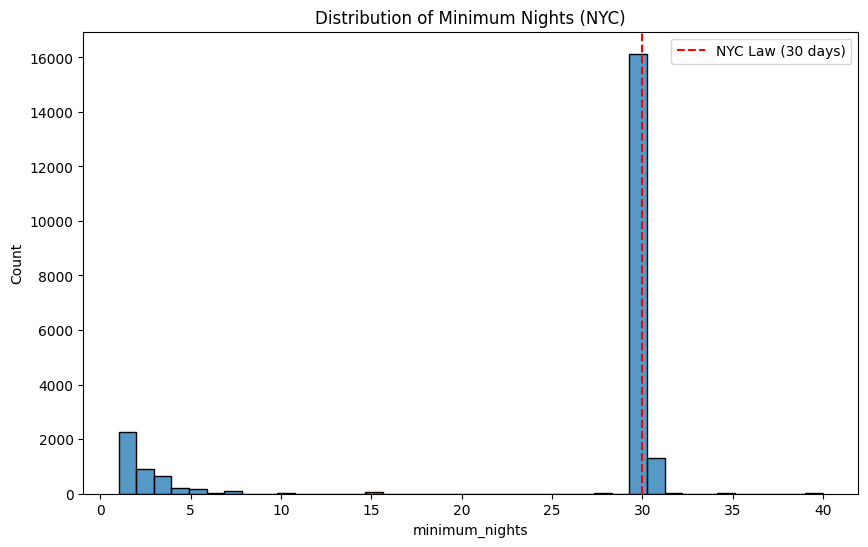

In [52]:
# 최소 숙박일수(minimum_nights) 분포 확인
# 30일(법적 기준) 근처에 데이터가 몰려있는지 확인하면 팀원들도 심각성을 깨달을 거야!
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df[df['minimum_nights'] <= 40]['minimum_nights'], bins=40)
plt.axvline(30, color='red', linestyle='--', label='NYC Law (30 days)')
plt.title('Distribution of Minimum Nights (NYC)')
plt.legend()
plt.show()

In [ ]:
import pandas as pd

# 1. 조건 설정: 집 전체(Entire home/apt) + 30일 미만 숙박(Short-term)
# 이 조건에 해당하면 무조건 뉴욕시 등록 번호(license)가 있어야 함
suspects = df[(df['room_type'] == 'Entire home/apt') & (df['minimum_nights'] < 30)].copy()

# 2. 라이선스 상태 분류하기
# - 결측치(NaN): 번호 없음 (위반 의심)
# - 'Exempt': 면제 대상이라고 주장 (실제 면제 건물인지 확인 필요)
# - 그 외: 번호 입력함 (진위 여부는 알 수 없으나 일단 입력)
def check_license(license_val):
    if pd.isna(license_val):
        return 'No License (Violation)'
    elif 'Exempt' in str(license_val):
        return 'Claimed Exempt'
    else:
        return 'License Provided'

suspects['license_status'] = suspects['license'].apply(check_license)

# 3. 결과 요약 출력
print("--- 꼼수형 호스트 의심 매물 요약 ---")
print(suspects['license_status'].value_counts())
print("\n" + "="*50)

# 4. 진짜 '배짱 영업' 리스트 10개만 보기
# 라이선스도 없는데 가격은 비싼 순서대로!
top_suspects = suspects[suspects['license_status'] == 'No License (Violation)'].nlargest(10, 'price')
print(top_suspects[['name', 'neighbourhood_cleansed', 'price', 'minimum_nights', 'license']])

--- 꼼수형 호스트 의심 매물 요약 ---
license_status
Claimed Exempt            948
License Provided          692
No License (Violation)      9
Name: count, dtype: int64



TypeError: Column 'price' has dtype str, cannot use method 'nlargest' with this dtype

In [60]:
suspects = df[(df['room_type'] == 'Entire home/apt') & (df['minimum_nights'] < 30)].copy()

print(suspects.value_counts)

<bound method DataFrame.value_counts of        Unnamed: 0                   id       source  \
3               3                38833  city scrape   
13             16                94783  city scrape   
146           216               248865  city scrape   
161           245               253466  city scrape   
162           246               253471  city scrape   
...           ...                  ...          ...   
21880       37000  1350130887670690892  city scrape   
21907       37027  1350437319146780555  city scrape   
21996       37116  1353965318849191034  city scrape   
22075       37195  1360899930891140524  city scrape   
22109       37229  1360911494336023398  city scrape   

                                                    name  \
3                     Spectacular West Harlem Garden Apt   
13        Beautiful, Bright’s, Warm & Spacious 1.5BR Apt   
146                                           Loft Suite   
161                                           Loft Suite   

--- 라이선스 상태별 가격 중앙값 ---
license
OSE-STRREG-0000756    3461.0
OSE-STRREG-0000018    2124.0
OSE-STRREG-0002657    1575.0
OSE-STRREG-0002307    1125.0
OSE-STRREG-1093331    1050.0
                       ...  
OSE-STRREG-0002294      81.0
OSE-STRREG-0002638      81.0
OSE-STRREG-0002001      81.0
OSE-STRREG-0002922      66.0
OSE-STRREG-0002817      66.0
Name: price, Length: 646, dtype: float64


/Users/cozygxurx/Desktop/심화프로젝트/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/cozygxurx/Desktop/심화프로젝트/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50521 (\N{HANGUL SYLLABLE ANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/cozygxurx/Desktop/심화프로젝트/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/cozygxurx/Desktop/심화프로젝트/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/cozygxurx/Desktop/심화프로젝트/.venv/lib/python3.12/si

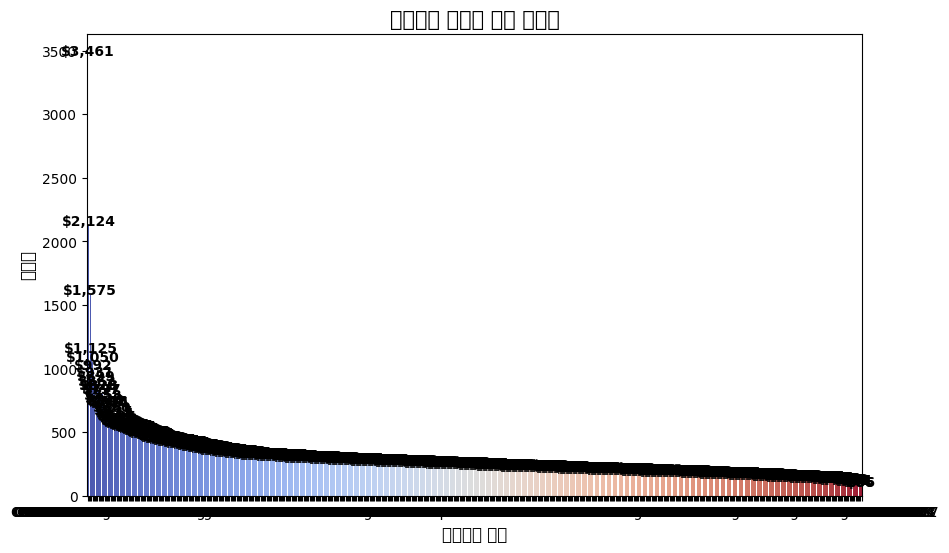

In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. price 컬럼을 숫자로 강제 변환 (문자열 제거 포함)
# .astype(str)을 먼저 해주는 게 안전해!
suspects['price'] = (
    suspects['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# 2. 'license' 대신 'license_status'로 그룹화해서 중앙값 계산
# (license_status: Violation, Exempt, Provided로 묶인 것)
license_price_median = suspects.groupby('license')['price'].median().sort_values(ascending=False)

print("--- 라이선스 상태별 가격 중앙값 ---")
print(license_price_median)

# 3. 시각화 (그래프까지 깔끔하게!)
plt.figure(figsize=(10, 6))
sns.barplot(x=license_price_median.index, y=license_price_median.values, hue=license_price_median.index, palette='coolwarm', legend=False)

plt.title('라이선스 상태별 가격 중앙값', fontsize=15)
plt.ylabel('중앙값', fontsize=12)
plt.xlabel('라이선스 상태', fontsize=12)

# 막대 위에 금액 표시
for i, v in enumerate(license_price_median.values):
    plt.text(i, v + 5, f"${v:,.0f}", ha='center', fontweight='bold')

plt.show()

--- 라이선스 상태별 가격 비교 (중앙값 vs 평균값) ---
                    Median         Mean
license                                
Exempt               235.0   334.957806
OSE-STRREG-0000010   255.0   255.000000
OSE-STRREG-0000013   296.0   296.000000
OSE-STRREG-0000018  2124.0  2124.000000
OSE-STRREG-0000020   139.0   139.000000
...                    ...          ...
Ose-strreg-0001336   172.0   172.000000
Ose-strreg-3603268   252.0   252.000000
ose-strreg-0000315    95.0    95.000000
ose-strreg-0001021   706.0   706.000000
ose-strreg-0002623   144.0   144.000000

[646 rows x 2 columns]


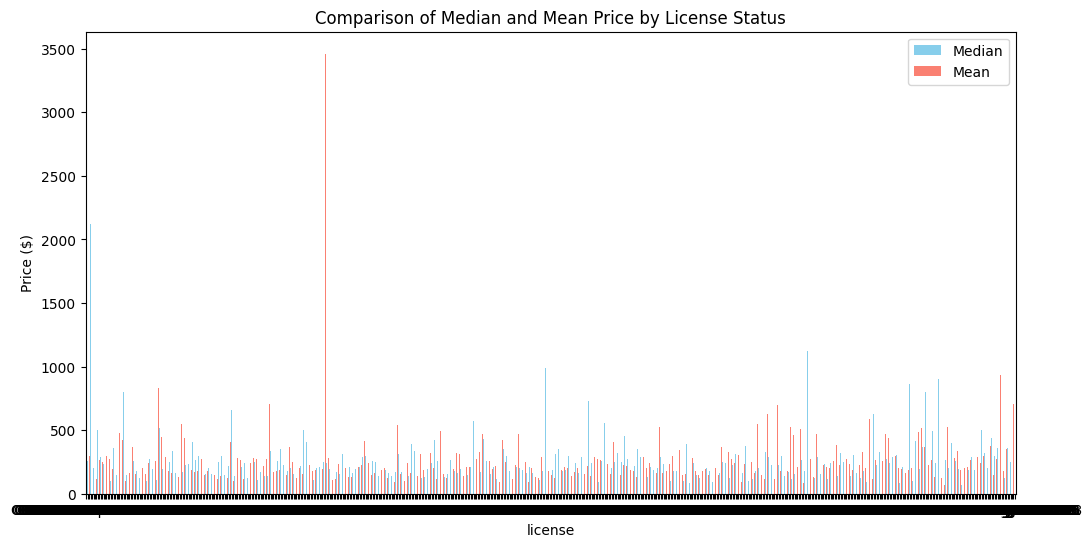

In [69]:
# 1. 라이선스 상태별 평균값(Mean) 계산
license_price_mean = suspects.groupby('license')['price'].mean().sort_values(ascending=False)

# 2. 중앙값과 평균값을 하나의 데이터프레임으로 합쳐서 보기
comparison_df = pd.DataFrame({
    'Median': license_price_median,
    'Mean': license_price_mean
})

print("--- 라이선스 상태별 가격 비교 (중앙값 vs 평균값) ---")
print(comparison_df)

# 3. 시각화 (평균과 중앙값 동시 비교)
comparison_df.plot(kind='bar', figsize=(12, 6), color=['skyblue', 'salmon'])
plt.title('Comparison of Median and Mean Price by License Status')
plt.ylabel('Price ($)')
plt.xticks(rotation=0)
plt.show()

In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정 (Mac/Windows 구분)
plt.rcParams['font.family'] = 'AppleGothic' # Mac용 (Windows면 'Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 라이선스 상태를 한글로 변환하는 매핑 딕셔너리
korean_labels = {
    'Claimed Exempt': '면제 대상(주장)',
    'License Provided': '라이선스 보유',
    'No License (Violation)': '라이선스 미보유(위반)'
}

# 3. 데이터프레임의 값을 한글로 변경
suspects['license_status_kor'] = suspects['license_status'].map(korean_labels)

# 4. 한글 상태별로 중앙값과 평균값 다시 계산
kor_price_stats = suspects.groupby('license_status_kor')['price'].agg(['median', 'mean']).sort_values(by='median', ascending=False)

# 5. 시각화
plt.figure(figsize=(12, 7))
kor_price_stats.plot(kind='bar', ax=plt.gca(), color=['#3498db', '#e74c3c'], width=0.8)

plt.title('뉴욕 에어비앤비 라이선스 상태별 가격 비교', fontsize=16, pad=20)
plt.ylabel('가격 (USD)', fontsize=12)
plt.xlabel('라이선스 등록 상태', fontsize=12)
plt.xticks(rotation=0) # 글자 똑바로 세우기
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(['중앙값(Median)', '평균값(Mean)'])

# 막대 위에 숫자 표시
for i, (med, avg) in enumerate(zip(kor_price_stats['median'], kor_price_stats['mean'])):
    plt.text(i - 0.2, med + 5, f'${med:,.0f}', ha='center', fontweight='bold', color='blue')
    plt.text(i + 0.2, avg + 5, f'${avg:,.0f}', ha='center', fontweight='bold', color='red')

plt.tight_layout()
plt.show()

KeyError: 'license_status'

--- 라이선스 보유 여부별 가격 통계 ---
  라이선스 여부    중앙값         평균값
0     미보유  130.0  197.040291
1      보유  182.0  280.988573


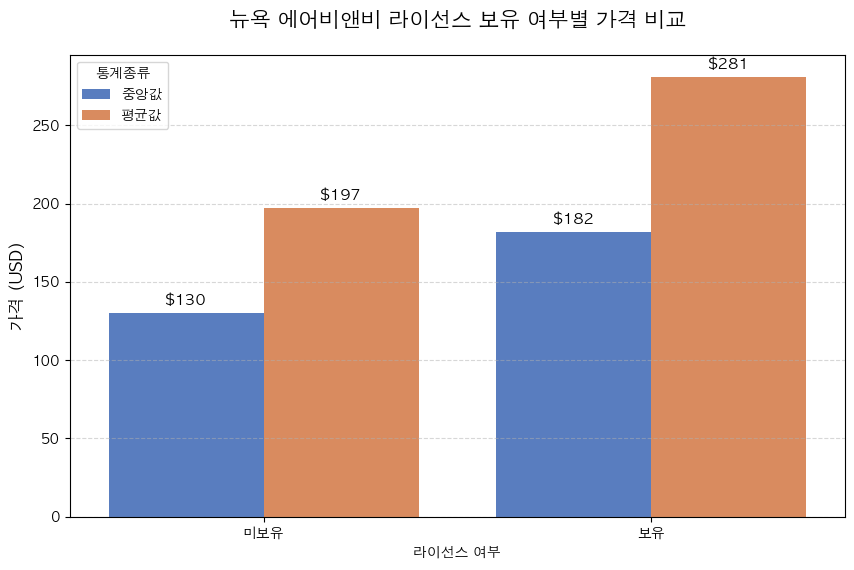

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'  # Mac
# plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
plt.rcParams['axes.unicode_minus'] = False

df['price'] = df['price'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)

# 라이선스 보유 여부 분류 ('license' 컬럼 활용) / 값이 있다면(notna) '보유', 없으면 '미보유'
df['라이선스_여부'] = df['license'].apply(lambda x: '보유' if pd.notna(x) else '미보유')

#보유 여부별 중앙값과 평균값 계산
license_stats = df.groupby('라이선스_여부')['price'].agg(['median', 'mean']).reset_index()
license_stats.columns = ['라이선스 여부', '중앙값', '평균값']

print("--- 라이선스 보유 여부별 가격 통계 ---")
print(license_stats)

# 5. 시각화 (중앙값과 평균값을 동시에 비교)
df_melted = license_stats.melt(id_vars='라이선스 여부', var_name='통계종류', value_name='가격')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='라이선스 여부', y='가격', hue='통계종류', palette='muted')

plt.title('뉴욕 에어비앤비 라이선스 보유 여부별 가격 비교', fontsize=15, pad=20)
plt.ylabel('가격 (USD)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 막대 위에 숫자 표시
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().text(p.get_x() + p.get_width()/2., height + 5,
                f'${height:,.0f}', ha='center', fontsize=11, fontweight='bold')

plt.show()